<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan upload file 'meuse.txt' melalui dialog di bawah:


Saving meuse.txt to meuse (4).txt

Jumlah data observasi yang digunakan: 155 baris.

 TABEL STATISTIK DESKRIPTIF (ZINC & COPPER)
        Count        Mean         Std    Min  Median     Max
zinc    155.0  469.716129  367.073788  113.0   326.0  1839.0
copper  155.0   40.316129   23.680436   14.0    31.0   128.0

 MATRIKS KORELASI PEARSON (LOG-ZINC & LOG-COPPER)
            log_zinc  log_copper
log_zinc    1.000000    0.897151
log_copper  0.897151    1.000000


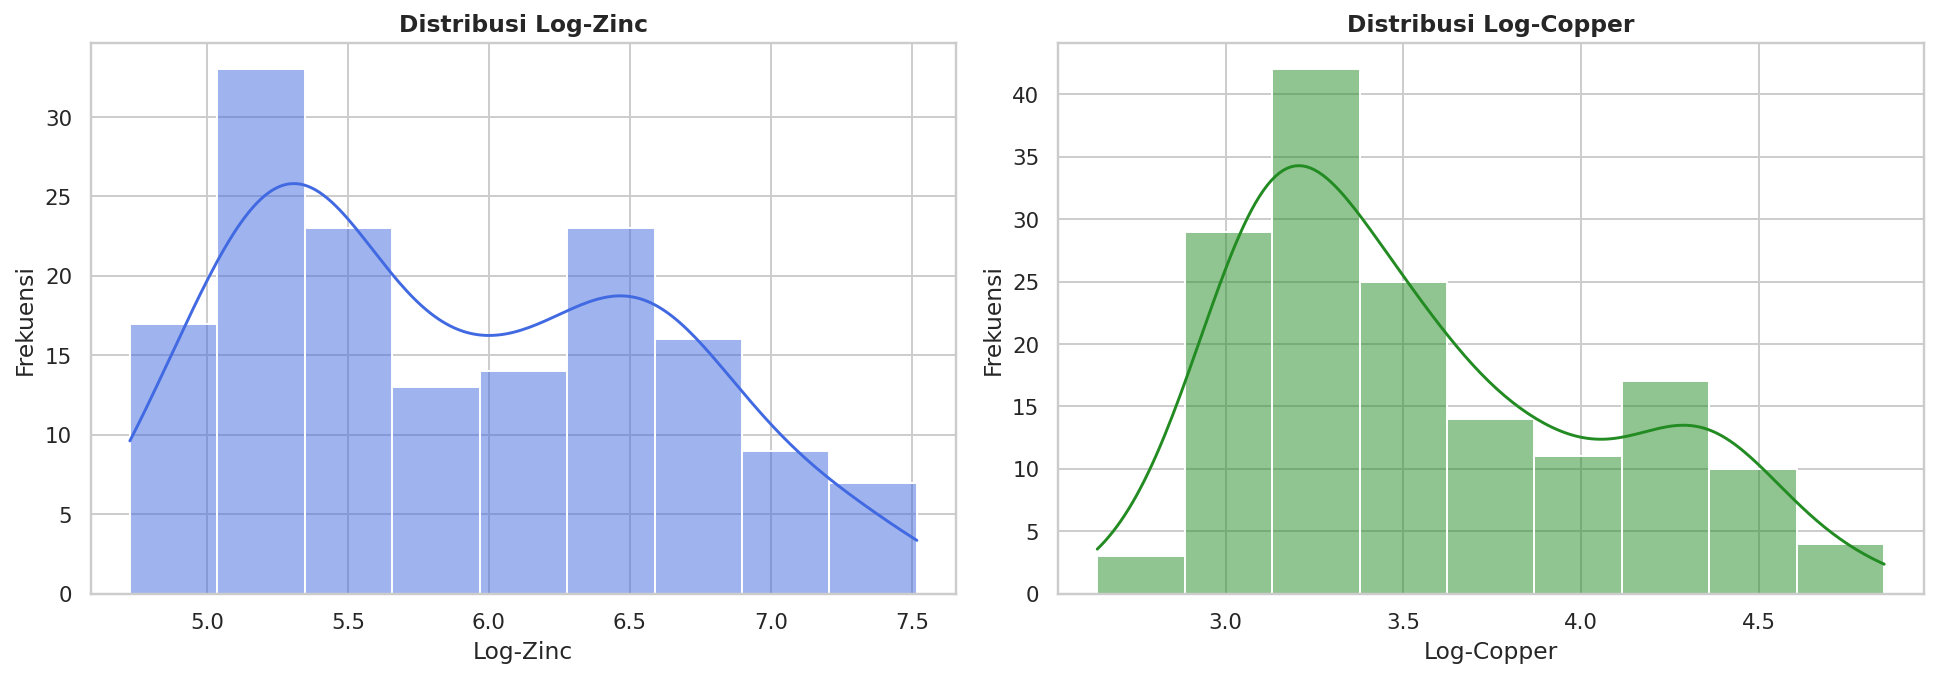

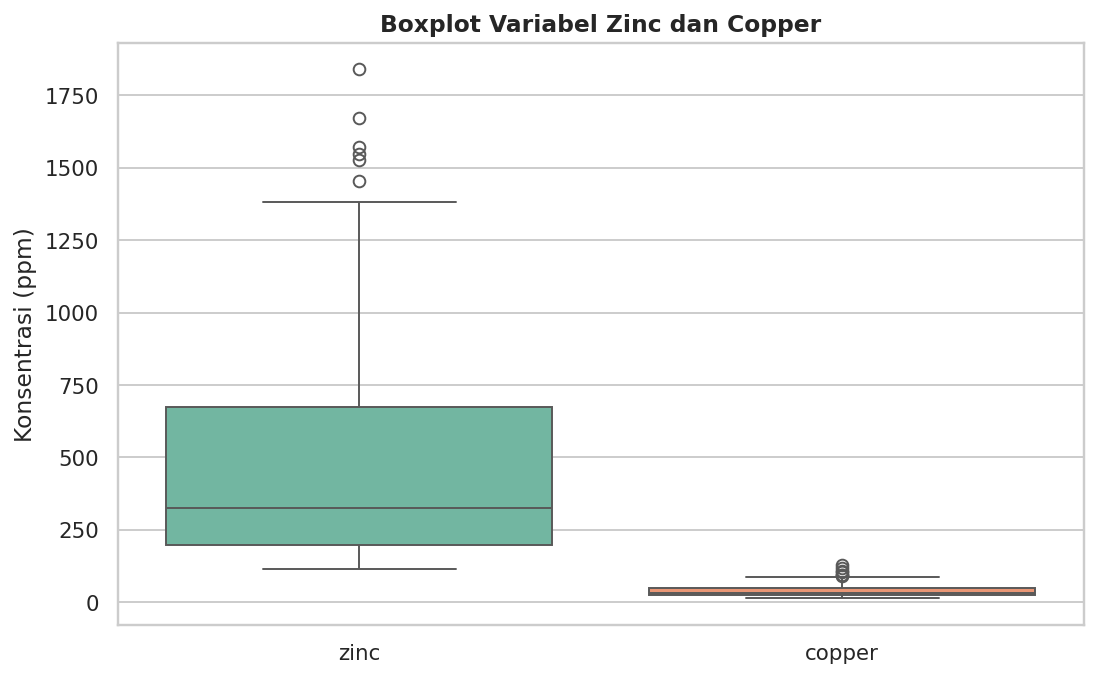

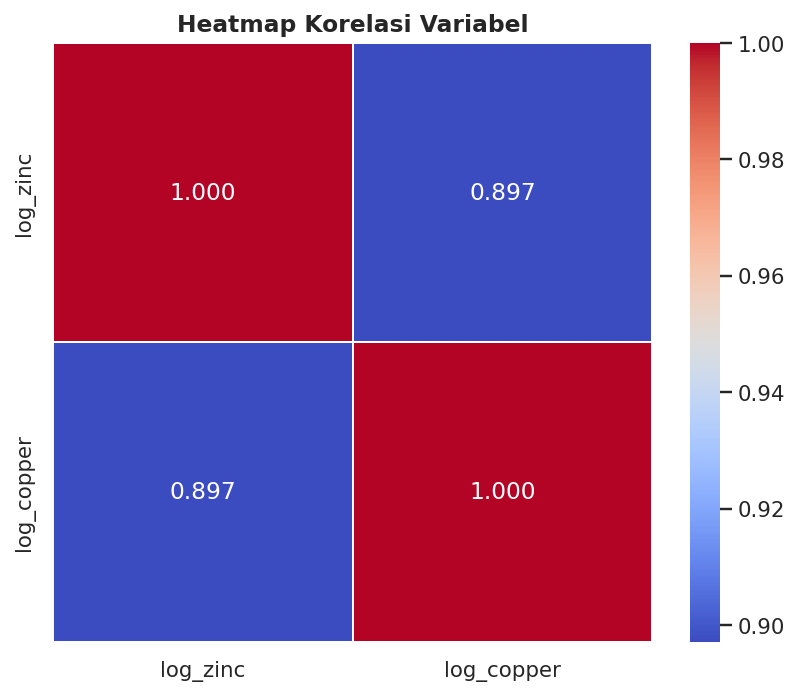

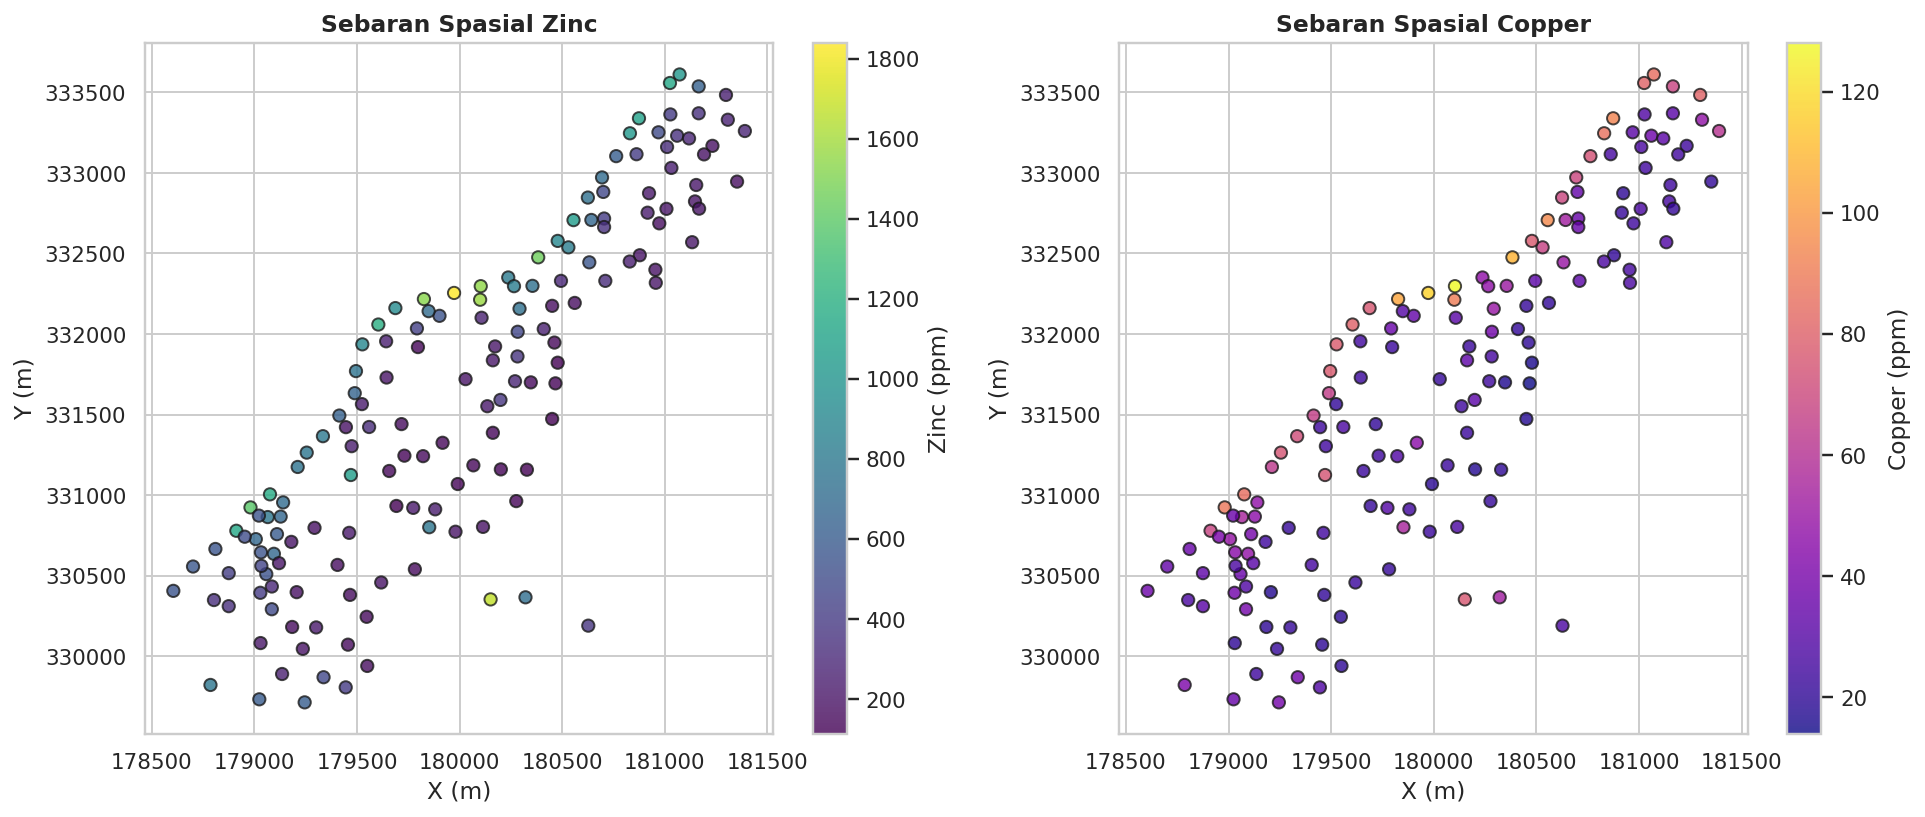

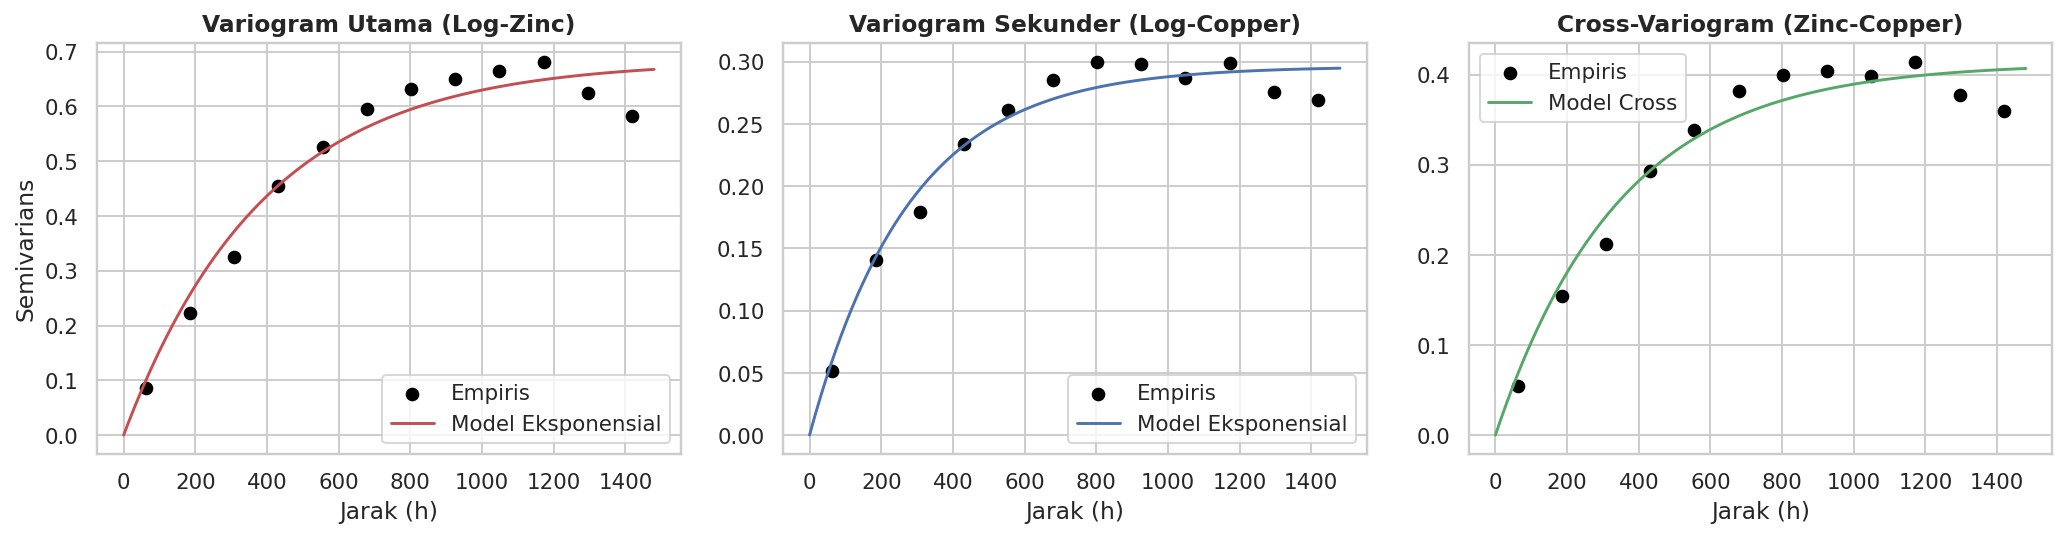


Menjalankan proses Validasi Silang (LOOCV)...

 HASIL EVALUASI VALIDASI SILANG (LOOCV)
 RMSE (Skala Log) : 0.3971
 R-Squared (R²)   : 0.6955
Membuat grid prediksi spasial akhir...


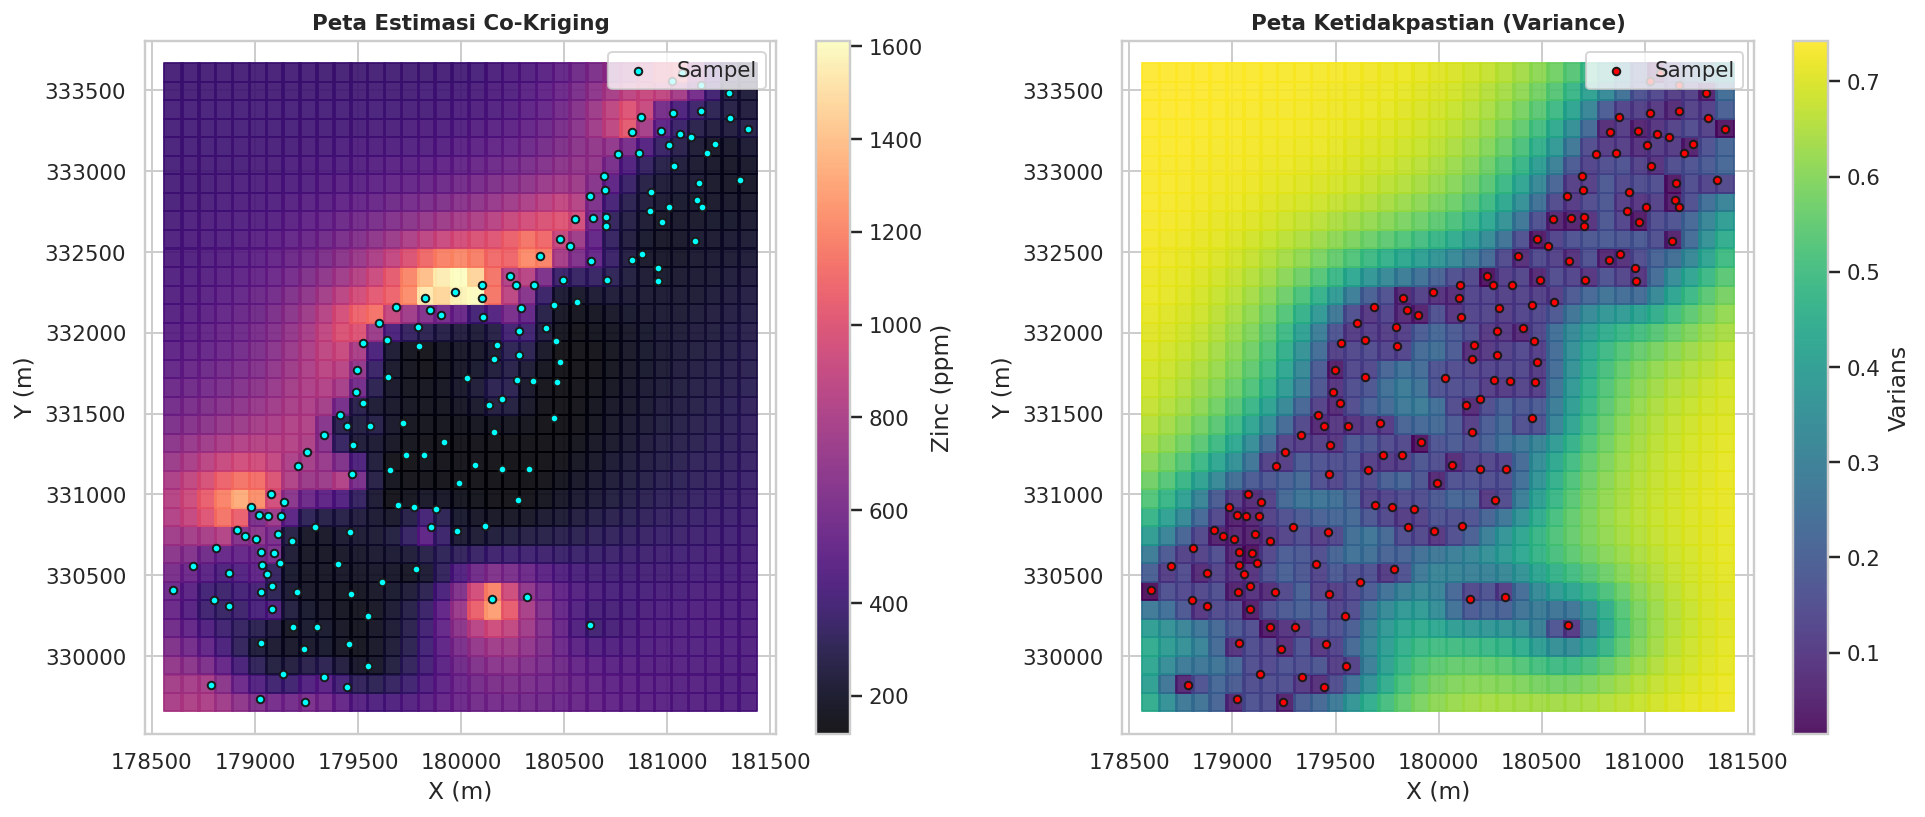

In [7]:
# ==============================================================================
# ORDINARY CO-KRIGING ANALISIS LOGAM BERAT (ZINC & COPPER)
# SCRIPT UTAMA KOMPUTASI SPASIAL
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# Pengaturan visualisasi grafik
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

# ==============================================================================
# 1. INPUT DATA DAN STATISTIK DESKRIPTIF (EDA)
# ==============================================================================
print("Silakan upload file 'meuse.txt' melalui dialog di bawah:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_meuse = pd.read_csv(filename).dropna(subset=['zinc', 'copper'])

print(f"\nJumlah data observasi yang digunakan: {len(df_meuse)} baris.")

# Tabel statistik deskriptif awal
print("\n" + "="*60)
print(" TABEL STATISTIK DESKRIPTIF (ZINC & COPPER)")
print("="*60)
desc_table = df_meuse[['zinc', 'copper']].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
desc_table.columns = ['Count', 'Mean', 'Std', 'Min', 'Median', 'Max']
print(desc_table.to_string())
print("="*60)

# Transformasi Log-Natural untuk menormalkan sebaran data
df_meuse['log_zinc'] = np.log(df_meuse['zinc'])
df_meuse['log_copper'] = np.log(df_meuse['copper'])

# Matriks korelasi variabel utama dan sekunder
print("\n" + "="*60)
print(" MATRIKS KORELASI PEARSON (LOG-ZINC & LOG-COPPER)")
print("="*60)
corr_matrix_table = df_meuse[['log_zinc', 'log_copper']].corr()
print(corr_matrix_table.to_string())
print("="*60)

# ==============================================================================
# 2. EKSPLORASI DAN VISUALISASI DATA (EDA)
# ==============================================================================
# A. Histogram dan kurva KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_meuse['log_zinc'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribusi Log-Zinc', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log-Zinc')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df_meuse['log_copper'], kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Distribusi Log-Copper', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log-Copper')
axes[1].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# B. Boxplot untuk deteksi pencilan (outlier)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_meuse[['zinc', 'copper']], palette='Set2')
plt.title('Boxplot Variabel Zinc dan Copper', fontsize=12, fontweight='bold')
plt.ylabel('Konsentrasi (ppm)')
plt.tight_layout()
plt.show()

# C. Heatmap korelasi
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix_table, annot=True, cmap='coolwarm', fmt='.3f', linewidths=1, cbar=True, square=True)
plt.title('Heatmap Korelasi Variabel', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# D. Sebaran koordinat spasial titik sampel
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc1 = axes[0].scatter(df_meuse['x'], df_meuse['y'], c=df_meuse['zinc'], cmap='viridis', s=40, edgecolors='k', alpha=0.8)
fig.colorbar(sc1, ax=axes[0], label='Zinc (ppm)')
axes[0].set_title('Sebaran Spasial Zinc', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')

sc2 = axes[1].scatter(df_meuse['x'], df_meuse['y'], c=df_meuse['copper'], cmap='plasma', s=40, edgecolors='k', alpha=0.8)
fig.colorbar(sc2, ax=axes[1], label='Copper (ppm)')
axes[1].set_title('Sebaran Spasial Copper', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. PERHITUNGAN VARIOGRAM EMPIRIS DAN CROSS-VARIOGRAM
# ==============================================================================
coords = df_meuse[['x', 'y']].values
z1 = df_meuse['log_zinc'].values
z2 = df_meuse['log_copper'].values

def compute_variogram(coords, z_a, z_b=None, n_lags=12, max_dist=None):
    dist_matrix = squareform(pdist(coords))
    if max_dist is None:
        max_dist = np.max(dist_matrix) / 3.0
    bins = np.linspace(0, max_dist, n_lags + 1)
    lags = 0.5 * (bins[:-1] + bins[1:])
    gamma_emp = []

    for i in range(n_lags):
        mask = (dist_matrix >= bins[i]) & (dist_matrix < bins[i+1])
        if np.sum(mask) > 0:
            dz_a = z_a[:, None] - z_a[None, :]
            if z_b is None:
                g = 0.5 * np.mean((dz_a[mask])**2)
            else:
                dz_b = z_b[:, None] - z_b[None, :]
                g = 0.5 * np.mean(dz_a[mask] * dz_b[mask])
            gamma_emp.append(g)
        else:
            gamma_emp.append(np.nan)
    return lags, np.array(gamma_emp)

max_d = np.max(pdist(coords)) / 3.0
lags, g_z1 = compute_variogram(coords, z1, max_dist=max_d)
lags, g_z2 = compute_variogram(coords, z2, max_dist=max_d)
lags, g_cross = compute_variogram(coords, z1, z2, max_dist=max_d)

# ==============================================================================
# 4. PEMILIHAN DAN FITTING MODEL TEORETIS VARIOGRAM
# ==============================================================================
# Alasan pemilihan model Eksponensial:
# Model eksponensial dipilih karena mampu merepresentasikan fenomena sebaran
# logam berat di tanah yang memiliki variabilitas spasial lokal sangat tinggi
# serta fluktuasi acak pada jarak dekat yang tajam.

def exponential_model(h, c0, c, a):
    h = np.asarray(h)
    return c0 + c * (1.0 - np.exp(-h / a))

def fit_model(lags, gamma_emp):
    def loss(params):
        c0, c, a = params
        if c0 < 0 or c < 0 or a <= 0:
            return 1e9
        pred = exponential_model(lags, c0, c, a)
        valid = ~np.isnan(gamma_emp)
        return np.sum((gamma_emp[valid] - pred[valid])**2)
    res = minimize(loss, [np.nanmin(gamma_emp), np.nanmax(gamma_emp)-np.nanmin(gamma_emp), max_d/2],
                   bounds=[(1e-4, None), (1e-4, None), (10, max_d*2)], method='L-BFGS-B')
    return res.x

p_11 = fit_model(lags, g_z1)
p_22 = fit_model(lags, g_z2)
p_12 = fit_model(lags, g_cross)

# Plot Fitting Model Teoretis
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(lags, g_z1, label='Empiris', color='black')
h_plot = np.linspace(0, max_d, 100)
plt.plot(h_plot, exponential_model(h_plot, *p_11), 'r-', label='Model Eksponensial')
plt.title('Variogram Utama (Log-Zinc)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.ylabel('Semivarians')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(lags, g_z2, label='Empiris', color='black')
plt.plot(h_plot, exponential_model(h_plot, *p_22), 'b-', label='Model Eksponensial')
plt.title('Variogram Sekunder (Log-Copper)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(lags, g_cross, label='Empiris', color='black')
plt.plot(h_plot, exponential_model(h_plot, *p_12), 'g-', label='Model Cross')
plt.title('Cross-Variogram (Zinc-Copper)', fontweight='bold')
plt.xlabel('Jarak (h)')
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. PEMBENTUKAN SISTEM MATRIKS ORDINARY CO-KRIGING
# ==============================================================================
def co_krig_predict_single(coords, z1, z2, target_coord):
    n = len(coords)
    D = squareform(pdist(coords))

    G11 = exponential_model(D, *p_11)
    G22 = exponential_model(D, *p_22)
    G12 = exponential_model(D, *p_12)

    sz = 2 * n + 2
    K = np.zeros((sz, sz))

    K[:n, :n] = G11
    K[:n, n:2*n] = G12
    K[n:2*n, :n] = G12.T
    K[n:2*n, n:2*n] = G22

    K[:n, 2*n] = 1.0
    K[2*n, :n] = 1.0
    K[n:2*n, 2*n+1] = 1.0
    K[2*n+1, n:2*n] = 1.0

    dt = np.sqrt(np.sum((coords - target_coord)**2, axis=1))

    k0 = np.zeros(sz)
    k0[:n] = exponential_model(dt, *p_11)
    k0[n:2*n] = exponential_model(dt, *p_12)
    k0[2*n] = 1.0
    k0[2*n+1] = 0.0

    try:
        K_stable = K.copy()
        np.fill_diagonal(K_stable[:2*n, :2*n], K_stable.diagonal()[:2*n] + 1e-5)

        weights = np.linalg.solve(K_stable, k0)
        lam1 = weights[:n]
        lam2 = weights[n:2*n]
        m1 = weights[2*n]

        log_pred = np.sum(lam1 * z1) + np.sum(lam2 * z2)
        variance = np.sum(lam1 * k0[:n]) + np.sum(lam2 * k0[n:2*n]) + m1
        return np.exp(log_pred), log_pred, max(0, variance)
    except:
        return np.exp(np.mean(z1)), np.mean(z1), 0.0

# ==============================================================================
# 6. VALIDASI SILANG (LOOCV)
# ==============================================================================
print("\nMenjalankan proses Validasi Silang (LOOCV)...")
y_true_log = z1
y_pred_log = []

for i in range(len(coords)):
    mask = np.ones(len(coords), dtype=bool)
    mask[i] = False
    _, l_pred, _ = co_krig_predict_single(coords[mask], z1[mask], z2[mask], coords[i])
    y_pred_log.append(l_pred)

y_pred_log = np.array(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2 = r2_score(y_true_log, y_pred_log)

print("\n" + "="*50)
print(" HASIL EVALUASI VALIDASI SILANG (LOOCV)")
print("="*50)
print(f" RMSE (Skala Log) : {rmse:.4f}")
print(f" R-Squared (R²)   : {r2:.4f}")
print("="*50)

# ==============================================================================
# 7. PEMETAAN SPASIAL HASIL INTERPOLASI
# ==============================================================================
print("Membuat grid prediksi spasial akhir...")
grid_x = np.linspace(df_meuse['x'].min(), df_meuse['x'].max(), 35)
grid_y = np.linspace(df_meuse['y'].min(), df_meuse['y'].max(), 35)
GX, GY = np.meshgrid(grid_x, grid_y)
G_coords = np.c_[GX.ravel(), GY.ravel()]

preds_original = []
co_krig_vars = []

for pt in G_coords:
    p_orig, _, var = co_krig_predict_single(coords, z1, z2, pt)
    preds_original.append(p_orig)
    co_krig_vars.append(var)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(G_coords[:, 0], G_coords[:, 1], c=preds_original, cmap='magma', s=90, marker='s', alpha=0.9)
axes[0].scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Sampel')
axes[0].set_title('Peta Estimasi Co-Kriging', fontsize=11, fontweight='bold')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].legend(loc='upper right')
fig.colorbar(sc1, ax=axes[0], label='Zinc (ppm)')

sc2 = axes[1].scatter(G_coords[:, 0], G_coords[:, 1], c=co_krig_vars, cmap='viridis', s=90, marker='s', alpha=0.9)
axes[1].scatter(df_meuse['x'], df_meuse['y'], c='red', s=15, edgecolors='k', label='Sampel')
axes[1].set_title('Peta Ketidakpastian (Variance)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].legend(loc='upper right')
fig.colorbar(sc2, ax=axes[1], label='Varians')

plt.tight_layout()
plt.show()